In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Force this notebook to use ONLY the requested run
RUN_DIR = Path('/home/rosdata/sensor_run_20260325_212948')
DATA_DIR = RUN_DIR / 'csv_export'
if not DATA_DIR.exists():
    DATA_DIR = RUN_DIR  # fallback if csv_export is missing

# Dark theme to match analyze_ekf_fusion.ipynb
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0',
    'axes.labelcolor': '#e0e0e0',
    'axes.titlecolor': '#e0e0e0',
    'text.color': '#e0e0e0',
    'xtick.color': '#aaaaaa',
    'ytick.color': '#aaaaaa',
    'grid.color': '#2a2a4a',
    'grid.alpha': 0.5,
    'legend.facecolor': '#16213e',
    'legend.edgecolor': '#444444',
    'savefig.facecolor': '#1a1a2e',
    'savefig.edgecolor': '#1a1a2e',
    'font.size': 11,
})

print('Using data folder:', DATA_DIR)
print('Exists:', DATA_DIR.exists())
print('Locked run:', RUN_DIR)
print('Theme applied: dark (analyze_ekf_fusion style)')

Using data folder: /home/rosdata/sensor_run_20260325_212948/csv_export
Exists: True
Locked run: /home/rosdata/sensor_run_20260325_212948
Theme applied: dark (analyze_ekf_fusion style)


In [19]:
# Statistical Analysis for Sensor Fusion (IMU accel/gyro focus)
def analyze_imu_for_fusion(df):
    if df is None or len(df) == 0:
        print('No IMU data available.')
        return

    target_cols = [
        'angular_velocity.x', 'angular_velocity.y', 'angular_velocity.z',
        'linear_acceleration.x', 'linear_acceleration.y', 'linear_acceleration.z',
    ]
    cols = [c for c in target_cols if c in df.columns]

    if len(cols) == 0:
        print('IMU accel/gyro columns not found in dataset.')
        return

    print('\n--- IMU (Accel/Gyro) Statistical Analysis ---')
    stats = df[cols].apply(pd.to_numeric, errors='coerce').agg(['mean', 'std', 'var', 'min', 'max']).T
    stats.columns = ['Mean (Bias)', 'StdDev (Noise)', 'Variance', 'Min', 'Max']
    print(stats.to_string())

    # Histograms for Gaussian/noise shape check
    df[cols].apply(pd.to_numeric, errors='coerce').hist(bins=60, figsize=(14, 8))
    plt.suptitle('IMU Accel/Gyro Noise Distribution')
    plt.tight_layout()
    plt.show()

if 'imu_df' in globals():
    analyze_imu_for_fusion(imu_df)
else:
    print("imu_df not found yet. Run the IMU loading cell first.")

imu_df not found yet. Run the IMU loading cell first.


In [21]:
# Discover available files + convert rosbag2 -> CSV (when needed)
csv_files = sorted(DATA_DIR.rglob('*.csv'))
parquet_files = sorted(DATA_DIR.rglob('*.parquet'))
db3_files = sorted(DATA_DIR.rglob('*.db3'))
mcap_files = sorted(DATA_DIR.rglob('*.mcap'))
metadata_files = sorted(DATA_DIR.rglob('metadata.yaml'))

print(f'DATA_DIR        : {DATA_DIR}')
print(f'CSV files       : {len(csv_files)}')
print(f'Parquet files   : {len(parquet_files)}')
print(f'ROS bag .db3    : {len(db3_files)}')
print(f'ROS bag .mcap   : {len(mcap_files)}')
print(f'Bag metadata    : {len(metadata_files)}')

if metadata_files:
    print('\nFound bag folders:')
    for m in metadata_files[:20]:
        print('-', m.parent)


def _flatten_dict(d, parent_key='', sep='.'):
    items = {}
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else str(k)
        if isinstance(v, dict):
            items.update(_flatten_dict(v, new_key, sep=sep))
        elif isinstance(v, (list, tuple)):
            # Keep short numeric vectors (e.g., covariance); skip very large arrays
            if len(v) <= 64:
                for i, val in enumerate(v):
                    items[f"{new_key}[{i}]"] = val
            else:
                items[f"{new_key}_len"] = len(v)
        else:
            items[new_key] = v
    return items


def convert_latest_bag_to_csv(data_dir: Path):
    """Convert key rosbag2 topics to CSV files under <bag>/csv_export."""
    try:
        import rosbag2_py
        from rclpy.serialization import deserialize_message
        from rosidl_runtime_py.utilities import get_message
        from rosidl_runtime_py.convert import message_to_ordereddict
    except Exception as exc:
        print(f'Cannot import rosbag2 conversion libs: {exc}')
        return None

    md = sorted(data_dir.rglob('metadata.yaml'), key=lambda p: p.stat().st_mtime)
    if not md:
        print('No bag metadata found to convert.')
        return None

    bag_dir = md[-1].parent
    storage_id = 'sqlite3' if any(bag_dir.glob('*.db3')) else 'mcap'
    out_dir = bag_dir / 'csv_export'
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f'\nConverting bag: {bag_dir}')
    print(f'Storage id: {storage_id}')
    print(f'Output dir: {out_dir}')

    selected_topics = [
        '/imu/data',
        '/gps/fix',
        '/diff_drive_controller/odom',
        '/cmd_vel',
        '/joint_states',
        '/lidar/points',
    ]

    reader = rosbag2_py.SequentialReader()
    storage_options = rosbag2_py.StorageOptions(uri=str(bag_dir), storage_id=storage_id)
    converter_options = rosbag2_py.ConverterOptions(
        input_serialization_format='cdr',
        output_serialization_format='cdr'
    )
    reader.open(storage_options, converter_options)

    topic_types = {t.name: t.type for t in reader.get_all_topics_and_types()}
    available = [t for t in selected_topics if t in topic_types]
    if not available:
        print('No selected topics found in this bag.')
        return out_dir

    rows = {t: [] for t in available}

    while reader.has_next():
        topic, data, t_ns = reader.read_next()
        if topic not in available:
            continue

        # Keep point cloud export lightweight (metadata only)
        if topic == '/lidar/points':
            msg_type = get_message(topic_types[topic])
            msg = deserialize_message(data, msg_type)
            row = {
                'bag_time_ns': int(t_ns),
                'header.frame_id': str(getattr(msg.header, 'frame_id', '')),
                'height': int(getattr(msg, 'height', 0)),
                'width': int(getattr(msg, 'width', 0)),
                'point_step': int(getattr(msg, 'point_step', 0)),
                'row_step': int(getattr(msg, 'row_step', 0)),
                'is_dense': bool(getattr(msg, 'is_dense', False)),
            }
            rows[topic].append(row)
            continue

        msg_type = get_message(topic_types[topic])
        msg = deserialize_message(data, msg_type)
        msg_dict = message_to_ordereddict(msg)
        flat = _flatten_dict(msg_dict)
        flat = {k: v for k, v in flat.items() if 'data' not in k.lower()}
        flat['bag_time_ns'] = int(t_ns)
        rows[topic].append(flat)

    for topic_name, topic_rows in rows.items():
        if not topic_rows:
            continue
        safe_name = topic_name.strip('/').replace('/', '__') + '.csv'
        out_path = out_dir / safe_name
        pd.DataFrame(topic_rows).to_csv(out_path, index=False)
        print(f'Wrote {len(topic_rows):6d} rows -> {out_path.name}')

    return out_dir


if not csv_files and not parquet_files and (db3_files or mcap_files):
    export_dir = convert_latest_bag_to_csv(DATA_DIR)
    if export_dir is not None:
        csv_files = sorted(DATA_DIR.rglob('*.csv'))
        parquet_files = sorted(DATA_DIR.rglob('*.parquet'))
        print(f'\nAfter conversion -> CSV: {len(csv_files)}, Parquet: {len(parquet_files)}')

if csv_files or parquet_files:
    print('\nTabular files to plot directly:')
    for f in (csv_files[:40] + parquet_files[:40]):
        print('-', f)
else:
    print('\nNo CSV/Parquet found yet.')

DATA_DIR        : /home/rosdata/sensor_run_20260325_212948/csv_export
CSV files       : 6
Parquet files   : 0
ROS bag .db3    : 0
ROS bag .mcap   : 0
Bag metadata    : 0

Tabular files to plot directly:
- /home/rosdata/sensor_run_20260325_212948/csv_export/cmd_vel.csv
- /home/rosdata/sensor_run_20260325_212948/csv_export/diff_drive_controller__odom.csv
- /home/rosdata/sensor_run_20260325_212948/csv_export/gps__fix.csv
- /home/rosdata/sensor_run_20260325_212948/csv_export/imu__data.csv
- /home/rosdata/sensor_run_20260325_212948/csv_export/joint_states.csv
- /home/rosdata/sensor_run_20260325_212948/csv_export/lidar__points.csv


In [24]:
def find_file(keywords):
    """Return first file whose path contains all keywords (case-insensitive)."""
    all_files = csv_files + parquet_files
    for f in all_files:
        s = str(f).lower()
        if all(k.lower() in s for k in keywords):
            return f
    return None

def load_table(path):
    if path is None:
        return None
    if path.suffix == '.csv':
        df = pd.read_csv(path)
    elif path.suffix == '.parquet':
        df = pd.read_parquet(path)
    else:
        return None

    # Guard against duplicate column names after flatten/export
    if df.columns.duplicated().any():
        df = df.loc[:, ~df.columns.duplicated()].copy()

    return df

def pick_time_col(df):
    candidates = ['time', 'timestamp', 'stamp', 'sec', 't', 'header.stamp', 'bag_time_ns']
    cols = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in cols:
            return cols[c]
    return df.columns[0]

def as_numeric(series):
    return pd.to_numeric(series, errors='coerce').to_numpy()

IMU file: /home/rosdata/sensor_run_20260325_212948/csv_export/imu__data.csv


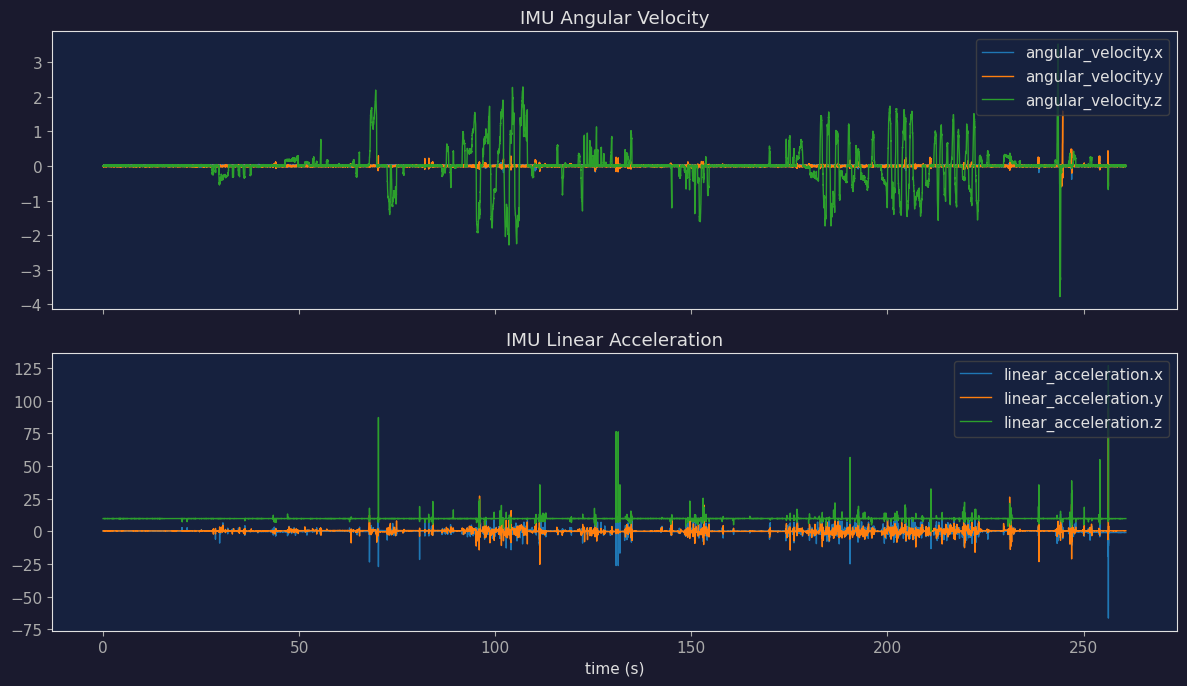

In [35]:
# IMU quick plot
imu_path = find_file(['imu'])
imu_df = load_table(imu_path)
print('IMU file:', imu_path)

if imu_df is not None and len(imu_df) > 0:
    tcol = pick_time_col(imu_df)
    t = as_numeric(imu_df[tcol])
    if tcol == 'bag_time_ns':
        t = (t - t[0]) * 1e-9  # convert ns to seconds from start

    fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    plotted_ang = 0
    for c in ['angular_velocity.x', 'angular_velocity.y', 'angular_velocity.z', 'wx', 'wy', 'wz']:
        if c in imu_df.columns:
            y = as_numeric(imu_df[c])
            ax[0].plot(t, y, label=c, linewidth=1)
            plotted_ang += 1
    ax[0].set_title('IMU Angular Velocity')
    if plotted_ang:
        ax[0].legend(loc='upper right')

    plotted_lin = 0
    for c in ['linear_acceleration.x', 'linear_acceleration.y', 'linear_acceleration.z', 'ax', 'ay', 'az']:
        if c in imu_df.columns:
            y = as_numeric(imu_df[c])
            ax[1].plot(t, y, label=c, linewidth=1)
            plotted_lin += 1
    ax[1].set_title('IMU Linear Acceleration')
    ax[1].set_xlabel('time (s)' if tcol == 'bag_time_ns' else tcol)
    if plotted_lin:
        ax[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()
else:
    print('No IMU table found. Rename/export file with imu in path or filename.')

GPS file: /home/rosdata/sensor_run_20260325_212948/csv_export/gps__fix.csv


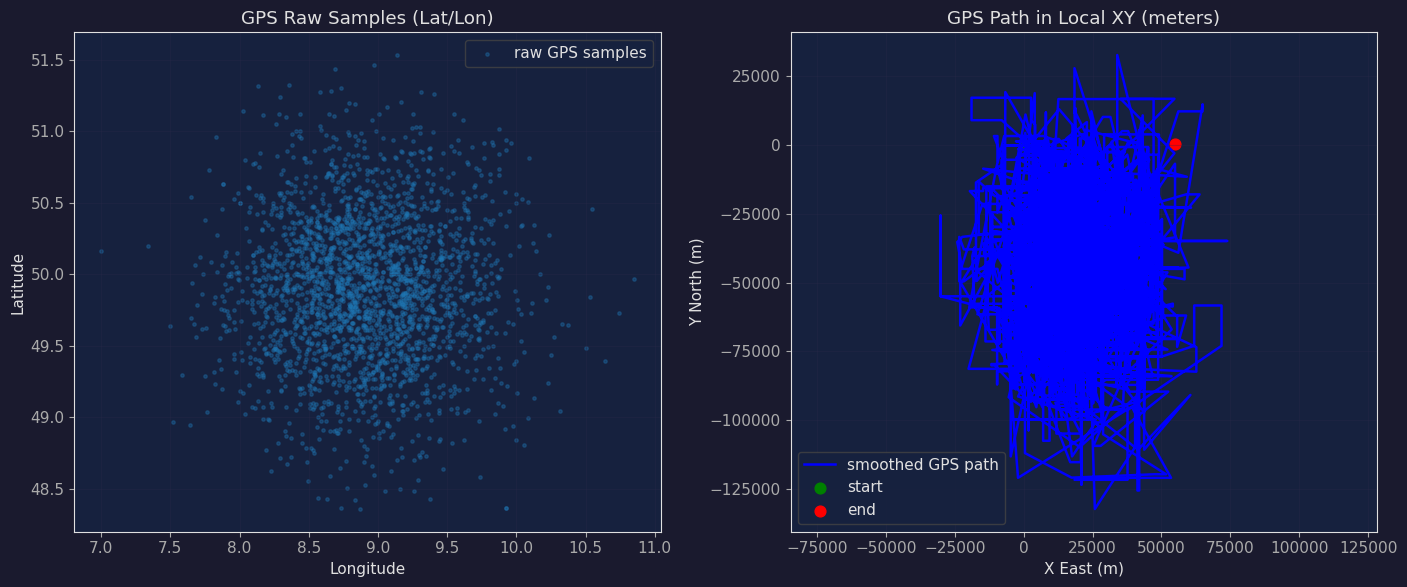

In [26]:
# GPS trajectory plot (fusion-friendly)
gps_path = find_file(['gps']) or find_file(['navsat'])
gps_df = load_table(gps_path)
print('GPS file:', gps_path)

if gps_df is not None and len(gps_df) > 0:
    lat_col = next((c for c in gps_df.columns if c.lower() in ['latitude', 'lat']), None)
    lon_col = next((c for c in gps_df.columns if c.lower() in ['longitude', 'lon', 'long']), None)
    tcol = pick_time_col(gps_df)

    if lat_col and lon_col:
        # numeric + valid
        df = gps_df[[tcol, lat_col, lon_col]].copy()
        df[tcol] = pd.to_numeric(df[tcol], errors='coerce')
        df[lat_col] = pd.to_numeric(df[lat_col], errors='coerce')
        df[lon_col] = pd.to_numeric(df[lon_col], errors='coerce')
        df = df.dropna()

        # IMPORTANT: sort by time before plotting trajectory
        df = df.sort_values(tcol).reset_index(drop=True)

        # Convert GPS lat/lon to local XY (meters) relative to first sample
        lat0 = np.deg2rad(df[lat_col].iloc[0])
        lon0 = np.deg2rad(df[lon_col].iloc[0])
        lat_r = np.deg2rad(df[lat_col].to_numpy())
        lon_r = np.deg2rad(df[lon_col].to_numpy())
        R = 6378137.0  # Earth radius (m)
        x = (lon_r - lon0) * np.cos(lat0) * R
        y = (lat_r - lat0) * R

        # Light smoothing for path readability (keeps raw too)
        win = 7
        x_s = pd.Series(x).rolling(win, center=True, min_periods=1).median().to_numpy()
        y_s = pd.Series(y).rolling(win, center=True, min_periods=1).median().to_numpy()

        fig, ax = plt.subplots(1, 2, figsize=(14, 6))

        # Raw geodetic scatter (good for noise visualization)
        ax[0].scatter(df[lon_col], df[lat_col], s=6, alpha=0.35, label='raw GPS samples')
        ax[0].set_title('GPS Raw Samples (Lat/Lon)')
        ax[0].set_xlabel('Longitude')
        ax[0].set_ylabel('Latitude')
        ax[0].grid(True, alpha=0.3)
        ax[0].legend()

        # Local XY path for motion interpretation
        ax[1].plot(x_s, y_s, '-b', linewidth=1.8, label='smoothed GPS path')
        ax[1].scatter(x[0], y[0], c='g', s=60, label='start')
        ax[1].scatter(x[-1], y[-1], c='r', s=60, label='end')
        ax[1].set_title('GPS Path in Local XY (meters)')
        ax[1].set_xlabel('X East (m)')
        ax[1].set_ylabel('Y North (m)')
        ax[1].axis('equal')
        ax[1].grid(True, alpha=0.3)
        ax[1].legend()

        plt.tight_layout()
        plt.show()

        # Expose for later fusion plots
        gps_local_df = pd.DataFrame({
            'time': df[tcol].to_numpy(),
            'x_gps_m': x,
            'y_gps_m': y,
            'x_gps_smooth_m': x_s,
            'y_gps_smooth_m': y_s,
        })
    else:
        print('GPS columns not found. Expected latitude/longitude style column names.')
else:
    print('No GPS table found.')

In [27]:
# GPS unit sanity check (critical before EKF fusion)
if 'gps_df' in globals() and gps_df is not None and len(gps_df) > 1:
    lat_col = next((c for c in gps_df.columns if c.lower() in ['latitude', 'lat']), None)
    lon_col = next((c for c in gps_df.columns if c.lower() in ['longitude', 'lon', 'long']), None)

    if lat_col and lon_col:
        lat = pd.to_numeric(gps_df[lat_col], errors='coerce').dropna().to_numpy()
        lon = pd.to_numeric(gps_df[lon_col], errors='coerce').dropna().to_numpy()

        lat_span_deg = float(np.max(lat) - np.min(lat)) if len(lat) else np.nan
        lon_span_deg = float(np.max(lon) - np.min(lon)) if len(lon) else np.nan

        # Rough conversion: 1 deg latitude ~ 111.32 km
        lat_span_km = lat_span_deg * 111.32
        lon_span_km = lon_span_deg * 111.32 * np.cos(np.deg2rad(np.nanmean(lat)))

        print('--- GPS Unit Sanity Check ---')
        print(f'Latitude span  : {lat_span_deg:.6f} deg (~{lat_span_km:.2f} km)')
        print(f'Longitude span : {lon_span_deg:.6f} deg (~{lon_span_km:.2f} km)')

        if lat_span_km > 1.0 or abs(lon_span_km) > 1.0:
            print('⚠️  Large geographic spread detected.')
            print('   This usually means:')
            print('   1) GPS noise is too large in simulation, or')
            print('   2) Data is not suitable as-is for EKF position update.')
            print('   Recommendation: record a new bag after GPS noise fix and use local XY conversion.')
        else:
            print('✅ GPS spread looks plausible for local robot motion.')
    else:
        print('GPS columns not found for sanity check.')
else:
    print('gps_df not available. Run the GPS loading/plot cell first.')

--- GPS Unit Sanity Check ---
Latitude span  : 3.175086 deg (~353.45 km)
Longitude span : 3.851957 deg (~276.23 km)
⚠️  Large geographic spread detected.
   This usually means:
   1) GPS noise is too large in simulation, or
   2) Data is not suitable as-is for EKF position update.
   Recommendation: record a new bag after GPS noise fix and use local XY conversion.


Odom file: /home/rosdata/sensor_run_20260325_212948/csv_export/diff_drive_controller__odom.csv


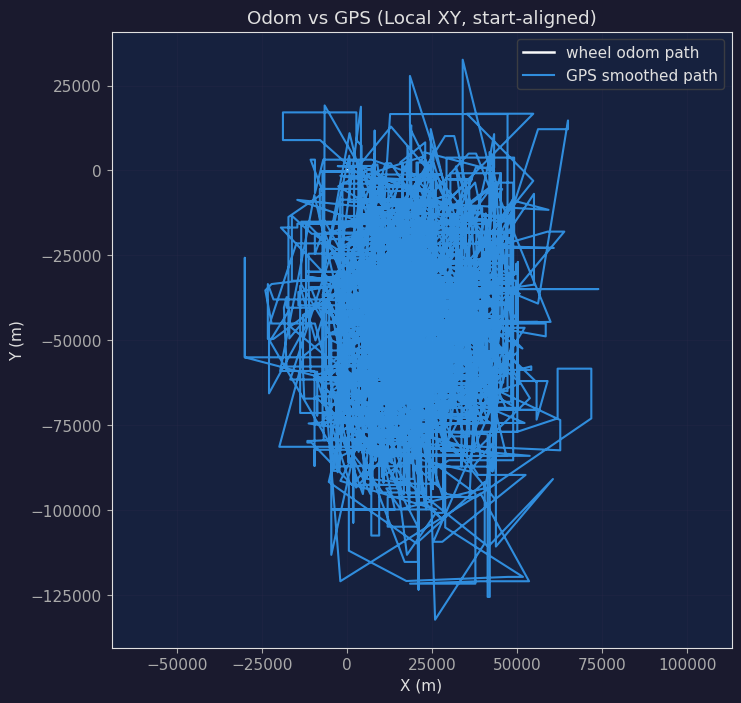

In [36]:
# Odom vs GPS local path (for sensor-fusion sanity check)
odom_path = find_file(['diff_drive_controller', 'odom']) or find_file(['odom'])
odom_df = load_table(odom_path)
print('Odom file:', odom_path)

if odom_df is not None and len(odom_df) > 0:
    # Common flattened names from rosbag conversion
    x_col = next((c for c in odom_df.columns if c.lower() in ['pose.pose.position.x', 'position.x', 'x']), None)
    y_col = next((c for c in odom_df.columns if c.lower() in ['pose.pose.position.y', 'position.y', 'y']), None)
    tcol = pick_time_col(odom_df)

    if x_col and y_col:
        od = odom_df[[tcol, x_col, y_col]].copy()
        od[tcol] = pd.to_numeric(od[tcol], errors='coerce')
        od[x_col] = pd.to_numeric(od[x_col], errors='coerce')
        od[y_col] = pd.to_numeric(od[y_col], errors='coerce')
        od = od.dropna().sort_values(tcol).reset_index(drop=True)

        x_odom = od[x_col].to_numpy()
        y_odom = od[y_col].to_numpy()

        # Shift odom start to (0,0) for easier comparison with local GPS
        x_odom = x_odom - x_odom[0]
        y_odom = y_odom - y_odom[0]

        plt.figure(figsize=(8, 8))
        plt.plot(x_odom, y_odom, color='#f8f9fa', linewidth=1.8, label='wheel odom path')

        if 'gps_local_df' in globals() and len(gps_local_df) > 0:
            plt.plot(
                gps_local_df['x_gps_smooth_m'].to_numpy(),
                gps_local_df['y_gps_smooth_m'].to_numpy(),
                color='#339af0', linewidth=1.5, alpha=0.9, label='GPS smoothed path'
            )

        plt.title('Odom vs GPS (Local XY, start-aligned)')
        plt.xlabel('X (m)')
        plt.ylabel('Y (m)')
        plt.axis('equal')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
    else:
        print('Could not find odom x/y columns in odom CSV.')
else:
    print('No odom CSV found yet.')

## Sensor Fusion Diagnostics (core plots)

These plots are typically used before EKF/UKF tuning:
- sensor sampling rates and timing stability
- command vs odometry velocity consistency
- covariance trends (GPS / IMU / odom)

In [30]:
# Build standardized time-series tables for fusion checks
def _time_seconds(df):
    tcol = pick_time_col(df)
    t = as_numeric(df[tcol])
    if tcol == 'bag_time_ns':
        t = (t - t[0]) * 1e-9
    else:
        t = t - np.nanmin(t)
    return t

fusion_tables = {}

if 'imu_df' in globals() and imu_df is not None and len(imu_df) > 0:
    fusion_tables['imu'] = pd.DataFrame({
        't': _time_seconds(imu_df),
        'wz': as_numeric(imu_df['angular_velocity.z']) if 'angular_velocity.z' in imu_df.columns else np.nan,
        'ax': as_numeric(imu_df['linear_acceleration.x']) if 'linear_acceleration.x' in imu_df.columns else np.nan,
        'ay': as_numeric(imu_df['linear_acceleration.y']) if 'linear_acceleration.y' in imu_df.columns else np.nan,
    })

odom_path = find_file(['diff_drive_controller', 'odom']) or find_file(['odom'])
odom_df = load_table(odom_path)
if odom_df is not None and len(odom_df) > 0:
    fusion_tables['odom'] = pd.DataFrame({
        't': _time_seconds(odom_df),
        'x': as_numeric(odom_df['pose.pose.position.x']) if 'pose.pose.position.x' in odom_df.columns else np.nan,
        'y': as_numeric(odom_df['pose.pose.position.y']) if 'pose.pose.position.y' in odom_df.columns else np.nan,
        'vx': as_numeric(odom_df['twist.twist.linear.x']) if 'twist.twist.linear.x' in odom_df.columns else np.nan,
        'wz': as_numeric(odom_df['twist.twist.angular.z']) if 'twist.twist.angular.z' in odom_df.columns else np.nan,
    })

cmd_path = find_file(['cmd_vel'])
cmd_df = load_table(cmd_path)
if cmd_df is not None and len(cmd_df) > 0:
    fusion_tables['cmd'] = pd.DataFrame({
        't': _time_seconds(cmd_df),
        'vx_cmd': as_numeric(cmd_df['linear.x']) if 'linear.x' in cmd_df.columns else np.nan,
        'wz_cmd': as_numeric(cmd_df['angular.z']) if 'angular.z' in cmd_df.columns else np.nan,
    })

gps_path = find_file(['gps']) or find_file(['navsat'])
gps_df = load_table(gps_path)
if gps_df is not None and len(gps_df) > 0 and all(c in gps_df.columns for c in ['latitude','longitude']):
    fusion_tables['gps'] = pd.DataFrame({
        't': _time_seconds(gps_df),
        'lat': as_numeric(gps_df['latitude']),
        'lon': as_numeric(gps_df['longitude']),
    })

lidar_path = find_file(['lidar']) or find_file(['points'])
lidar_df = load_table(lidar_path)
if lidar_df is not None and len(lidar_df) > 0 and 'width' in lidar_df.columns:
    fusion_tables['lidar'] = pd.DataFrame({
        't': _time_seconds(lidar_df),
        'width': as_numeric(lidar_df['width']),
    })

print('Loaded fusion tables:')
for k, v in fusion_tables.items():
    print(f'  {k:5s}: {len(v):6d} rows')

Loaded fusion tables:
  imu  :  49984 rows
  odom :  12495 rows
  cmd  :  12249 rows
  gps  :   2499 rows
  lidar:   1249 rows


imu   median rate:  198.80 Hz | mean rate: 18047.35 Hz | p95: 124271.47 Hz | p99: 224315.84 Hz
odom  median rate:   48.83 Hz | mean rate:   48.16 Hz | p95:   50.38 Hz | p99:   51.06 Hz
gps   median rate:    9.71 Hz | mean rate:    9.60 Hz | p95:   10.10 Hz | p99:   10.52 Hz
lidar median rate:    4.83 Hz | mean rate:    5.11 Hz | p95:    9.42 Hz | p99:    9.77 Hz
cmd   median rate:  202.56 Hz | mean rate:  403.40 Hz | p95: 1069.77 Hz | p99: 1666.91 Hz


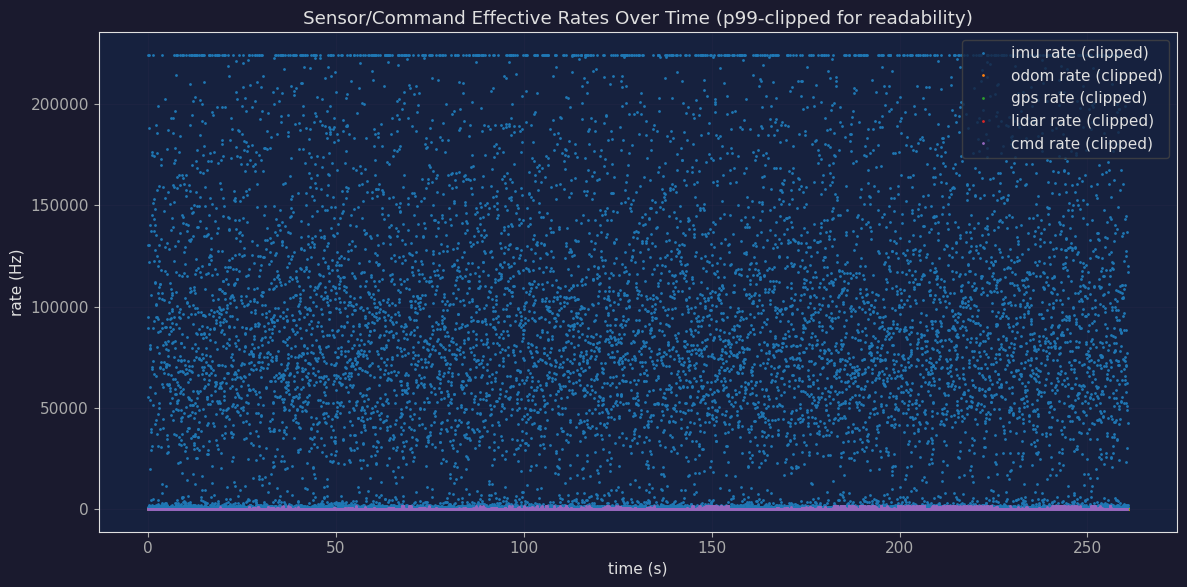

In [31]:
# Plot 1: Sensor timing and effective rates (robust)
plt.figure(figsize=(12, 6))
for name in ['imu', 'odom', 'gps', 'lidar', 'cmd']:
    if name not in fusion_tables:
        continue
    t = fusion_tables[name]['t'].to_numpy()
    t = t[np.isfinite(t)]
    if len(t) < 3:
        continue

    dt = np.diff(t)
    dt = dt[(dt > 0) & np.isfinite(dt)]
    if len(dt) == 0:
        continue

    rate = 1.0 / dt
    # Remove unrealistic spikes for display only
    r95 = np.percentile(rate, 95)
    r99 = np.percentile(rate, 99)
    rate_plot = np.clip(rate, 0, r99)

    t_plot = t[1:1+len(rate_plot)]
    plt.plot(t_plot, rate_plot, '.', markersize=2, label=f'{name} rate (clipped)')

    print(
        f"{name:5s} median rate: {np.median(rate):7.2f} Hz | "
        f"mean rate: {np.mean(rate):7.2f} Hz | p95: {r95:7.2f} Hz | p99: {r99:7.2f} Hz"
    )

plt.title('Sensor/Command Effective Rates Over Time (p99-clipped for readability)')
plt.xlabel('time (s)')
plt.ylabel('rate (Hz)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

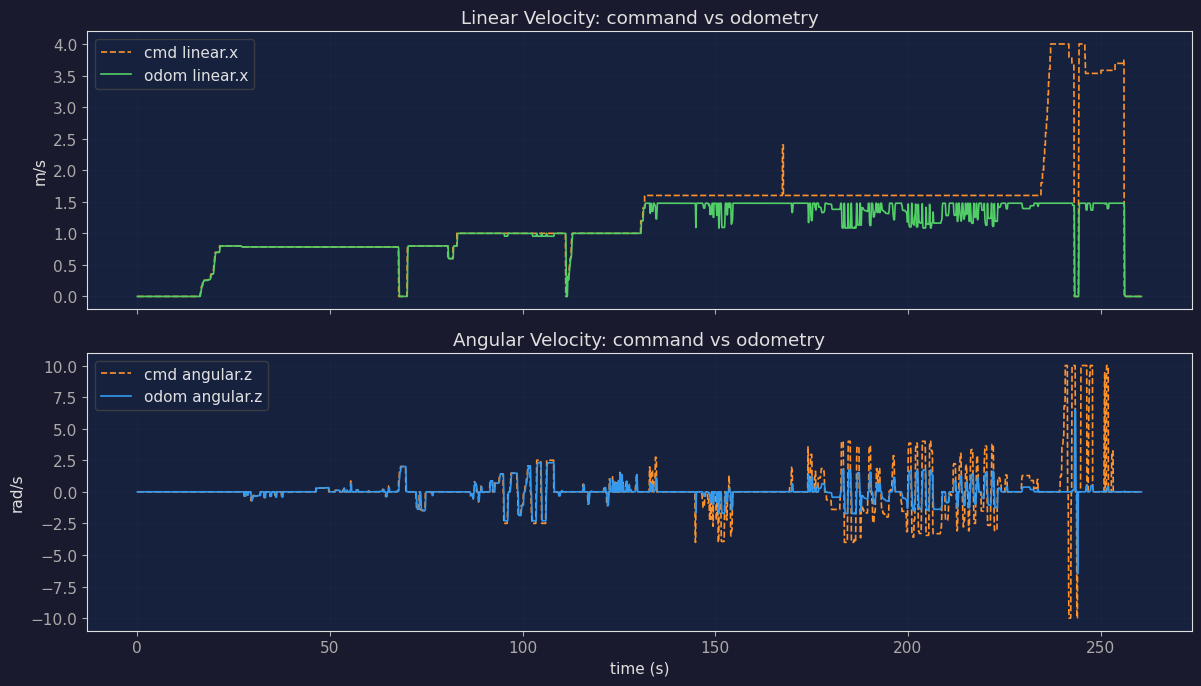

RMSE linear.x  : 0.7022662264263196
RMSE angular.z : 2.087918348668186


In [32]:
# Plot 2: Commanded vs measured velocity (odom)
if 'cmd' in fusion_tables and 'odom' in fusion_tables:
    cmd = fusion_tables['cmd'].dropna().sort_values('t')
    od = fusion_tables['odom'].dropna().sort_values('t')

    t_cmd = cmd['t'].to_numpy()
    vx_cmd = cmd['vx_cmd'].to_numpy()
    wz_cmd = cmd['wz_cmd'].to_numpy()

    t_od = od['t'].to_numpy()
    vx_od = od['vx'].to_numpy()
    wz_od = od['wz'].to_numpy()

    # interpolate odom to command timestamps
    vx_od_i = np.interp(t_cmd, t_od, vx_od)
    wz_od_i = np.interp(t_cmd, t_od, wz_od)

    fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    ax[0].plot(t_cmd, vx_cmd, color='#ff922b', linestyle='--', linewidth=1.2, label='cmd linear.x')
    ax[0].plot(t_cmd, vx_od_i, color='#51cf66', linewidth=1.2, label='odom linear.x')
    ax[0].set_ylabel('m/s')
    ax[0].set_title('Linear Velocity: command vs odometry')
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].plot(t_cmd, wz_cmd, color='#ff922b', linestyle='--', linewidth=1.2, label='cmd angular.z')
    ax[1].plot(t_cmd, wz_od_i, color='#339af0', linewidth=1.2, label='odom angular.z')
    ax[1].set_ylabel('rad/s')
    ax[1].set_xlabel('time (s)')
    ax[1].set_title('Angular Velocity: command vs odometry')
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    print('RMSE linear.x  :', float(np.sqrt(np.nanmean((vx_cmd - vx_od_i) ** 2))))
    print('RMSE angular.z :', float(np.sqrt(np.nanmean((wz_cmd - wz_od_i) ** 2))))
else:
    print('Need both cmd_vel and odom tables for this plot.')

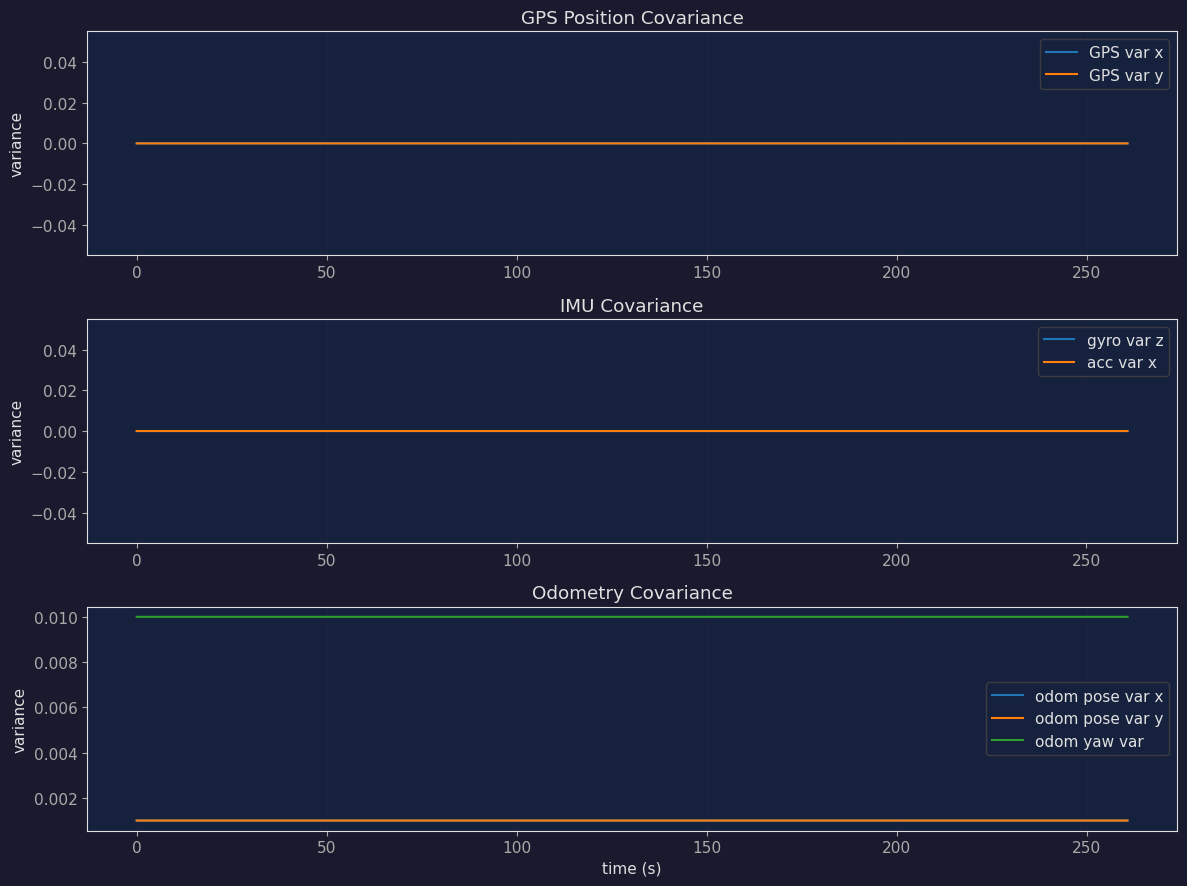

In [33]:
# Plot 3: Covariance / uncertainty trends used for EKF tuning
fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=False)

# GPS covariance (position)
if 'gps_df' in globals() and gps_df is not None and len(gps_df) > 0:
    if all(c in gps_df.columns for c in ['position_covariance[0]', 'position_covariance[4]']):
        t = _time_seconds(gps_df)
        gps_var_x = as_numeric(gps_df['position_covariance[0]'])
        gps_var_y = as_numeric(gps_df['position_covariance[4]'])
        ax[0].plot(t, gps_var_x, label='GPS var x')
        ax[0].plot(t, gps_var_y, label='GPS var y')
        ax[0].set_title('GPS Position Covariance')
        ax[0].set_ylabel('variance')
        ax[0].grid(True, alpha=0.3)
        ax[0].legend()

# IMU covariance
if 'imu_df' in globals() and imu_df is not None and len(imu_df) > 0:
    t = _time_seconds(imu_df)
    imu_cov_cols = [
        ('angular_velocity_covariance[8]', 'gyro var z'),
        ('linear_acceleration_covariance[0]', 'acc var x'),
    ]
    plotted = 0
    for col, label in imu_cov_cols:
        if col in imu_df.columns:
            ax[1].plot(t, as_numeric(imu_df[col]), label=label)
            plotted += 1
    if plotted:
        ax[1].set_title('IMU Covariance')
        ax[1].set_ylabel('variance')
        ax[1].grid(True, alpha=0.3)
        ax[1].legend()

# Odom covariance
if 'odom_df' in globals() and odom_df is not None and len(odom_df) > 0:
    t = _time_seconds(odom_df)
    odom_cov_cols = [
        ('pose.covariance[0]', 'odom pose var x'),
        ('pose.covariance[7]', 'odom pose var y'),
        ('pose.covariance[35]', 'odom yaw var'),
    ]
    plotted = 0
    for col, label in odom_cov_cols:
        if col in odom_df.columns:
            ax[2].plot(t, as_numeric(odom_df[col]), label=label)
            plotted += 1
    if plotted:
        ax[2].set_title('Odometry Covariance')
        ax[2].set_xlabel('time (s)')
        ax[2].set_ylabel('variance')
        ax[2].grid(True, alpha=0.3)
        ax[2].legend()

plt.tight_layout()
plt.show()

Point cloud file: /home/rosdata/sensor_run_20260325_212948/csv_export/lidar__points.csv


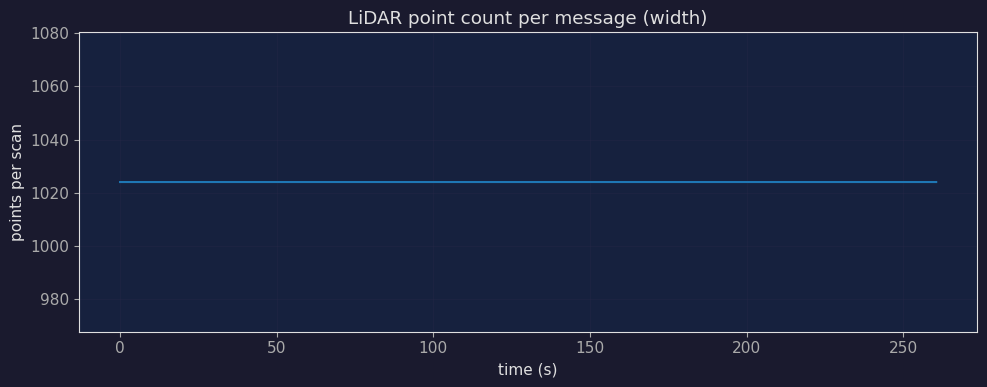

In [34]:
# LiDAR quick check
pc_path = find_file(['lidar']) or find_file(['points'])
pc_df = load_table(pc_path)
print('Point cloud file:', pc_path)

if pc_df is not None and len(pc_df) > 0:
    xyz = [c for c in pc_df.columns if c.lower() in ['x', 'y', 'z']]

    if len(xyz) >= 3:
        sample = pc_df.sample(min(30000, len(pc_df)), random_state=1)
        x = as_numeric(sample['x'])
        y = as_numeric(sample['y'])
        valid = np.isfinite(x) & np.isfinite(y)
        plt.figure(figsize=(8, 8))
        plt.scatter(x[valid], y[valid], s=1, alpha=0.5)
        plt.title('LiDAR XY (downsampled)')
        plt.xlabel('x (m)')
        plt.ylabel('y (m)')
        plt.axis('equal')
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        # Fallback for lightweight PointCloud2 metadata export
        if 'bag_time_ns' in pc_df.columns and 'width' in pc_df.columns:
            t = as_numeric(pc_df['bag_time_ns'])
            t = (t - t[0]) * 1e-9
            width = as_numeric(pc_df['width'])
            valid = np.isfinite(t) & np.isfinite(width)

            plt.figure(figsize=(10, 4))
            plt.plot(t[valid], width[valid], linewidth=1.5)
            plt.title('LiDAR point count per message (width)')
            plt.xlabel('time (s)')
            plt.ylabel('points per scan')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print('No x/y/z columns found in this LiDAR table.')
else:
    print('No LiDAR/points table found.')

## Next step (if your data is still rosbag2)
If you only have rosbag2 files (`.db3` / `.mcap`) and no CSV/Parquet yet, export topics first, then rerun this notebook.

You can keep this notebook simple by exporting only:
- IMU (`/imu/data`)
- GPS (`/gps/fix`)
- LiDAR points (`/lidar/points`)